<a href="https://colab.research.google.com/github/tommypolpo/geron-hands_on_ML/blob/main/c8_ex10_ex11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The classic Olivetti faces dataset contains 400 grayscale 64 × 64–pixel images of faces. Each image is flattened to a 1D vector of size 4,096. 40 different people were photographed (10 times each), and the usual task is to train a model that can predict which person is represented in each picture. Load the dataset using the sklearn.`datasets.fetch_olivetti_faces()` function.

Split it in training, validation and test set. Use stratified sampling to ensure there are the same number of impages per person.

Cluster the images using k-means and ensure you have a good number of clusters. Visualize the clusters.


In [2]:
from sklearn.datasets import fetch_olivetti_faces
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


faces = fetch_olivetti_faces()

downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /root/scikit_learn_data


In [3]:
faces.images[0]

array([[0.30991736, 0.3677686 , 0.41735536, ..., 0.37190083, 0.3305785 ,
        0.30578512],
       [0.3429752 , 0.40495867, 0.43801653, ..., 0.37190083, 0.338843  ,
        0.3140496 ],
       [0.3429752 , 0.41735536, 0.45041323, ..., 0.38016528, 0.338843  ,
        0.29752067],
       ...,
       [0.21487603, 0.20661157, 0.2231405 , ..., 0.15289256, 0.16528925,
        0.17355372],
       [0.20247933, 0.2107438 , 0.2107438 , ..., 0.14876033, 0.16115703,
        0.16528925],
       [0.20247933, 0.20661157, 0.20247933, ..., 0.15289256, 0.16115703,
        0.1570248 ]], dtype=float32)

In [4]:
faces.target

array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,
        3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  4,  4,  4,  4,  4,  5,
        5,  5,  5,  5,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,  6,  6,
        6,  6,  7,  7,  7,  7,  7,  7,  7,  7,  7,  7,  8,  8,  8,  8,  8,
        8,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9,  9,  9,  9,  9, 10, 10,
       10, 10, 10, 10, 10, 10, 10, 10, 11, 11, 11, 11, 11, 11, 11, 11, 11,
       11, 12, 12, 12, 12, 12, 12, 12, 12, 12, 12, 13, 13, 13, 13, 13, 13,
       13, 13, 13, 13, 14, 14, 14, 14, 14, 14, 14, 14, 14, 14, 15, 15, 15,
       15, 15, 15, 15, 15, 15, 15, 16, 16, 16, 16, 16, 16, 16, 16, 16, 16,
       17, 17, 17, 17, 17, 17, 17, 17, 17, 17, 18, 18, 18, 18, 18, 18, 18,
       18, 18, 18, 19, 19, 19, 19, 19, 19, 19, 19, 19, 19, 20, 20, 20, 20,
       20, 20, 20, 20, 20, 20, 21, 21, 21, 21, 21, 21, 21, 21, 21, 21, 22,
       22, 22, 22, 22, 22

In [5]:
print(faces.target.shape)
print(faces.target[1])
print(faces.target[45])

(400,)
0
4


faces.data contains the 400 "flattened" pictures. faces.target contains the labels

In [6]:
from sklearn.model_selection import train_test_split
X = faces.data  # shape is (400, 4069)
y = faces.target  # the labels

# First split: 80% train, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Second split: split temporary into validation and test
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.995)
X_train_pca = pca.fit_transform(X_train)
X_valid_pca = pca.transform(X_valid)
X_test_pca = pca.transform(X_test)

pca.n_components_  # 256 which is quite less than 4096

np.int64(256)

In [8]:
from sklearn.cluster import KMeans

ks = range(5,150, 5)  # 5,10,15,20,...,150
kmeans_models = []
for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)
    kmeans_models.append(kmeans)


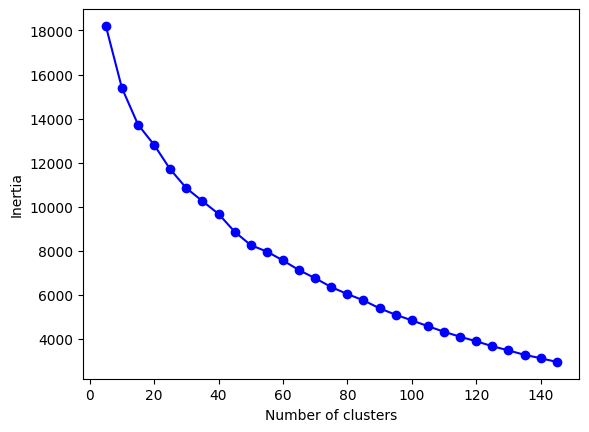

In [9]:
# we print the model inertias

inertias = [model.inertia_ for model in kmeans_models]

plt.plot(ks, inertias, "bo-")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

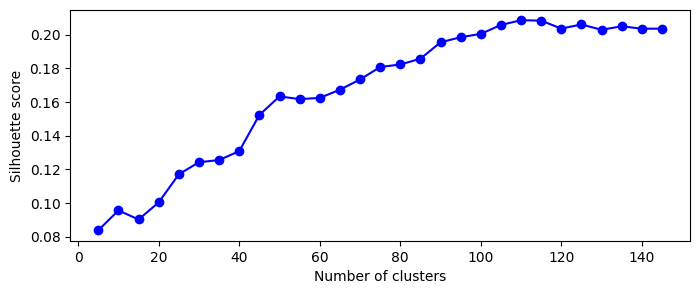

In [10]:
# and the models siluhettes
from sklearn.metrics import silhouette_score

silhouettes = [silhouette_score(X_train_pca, model.labels_) for model in kmeans_models]

best_index = np.argmax(silhouettes) ## the index of the silhouettes vectors
best_k = ks[best_index] # the corresponding number of clusters
best_score = silhouettes[best_index] # the correspondign silhouette score

plt.figure(figsize=(8, 3))
plt.plot(ks, silhouettes, "bo-")
plt.xlabel("Number of clusters")
plt.ylabel("Silhouette score")
plt.show()





In [11]:
best_k

110

In [12]:
best_model = kmeans_models[best_index]

Cluster 0


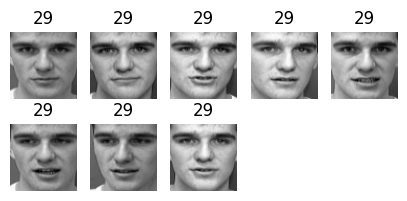

Cluster 1


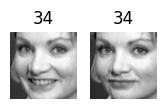

Cluster 2


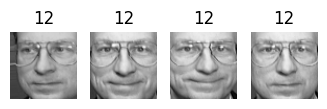

Cluster 3


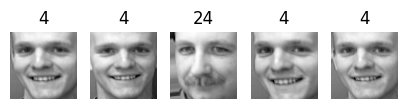

Cluster 4


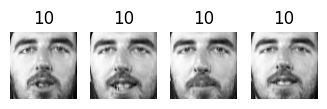

Cluster 5


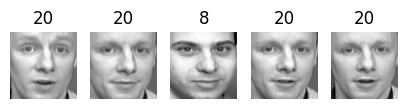

Cluster 6


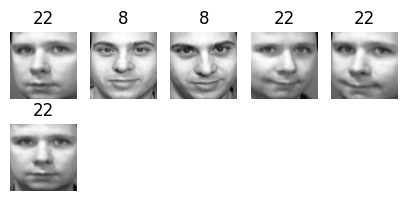

Cluster 7


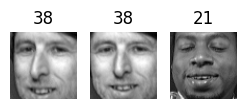

Cluster 8


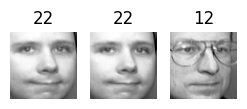

Cluster 9


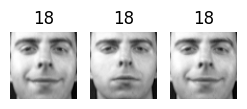

Cluster 10


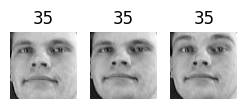

Cluster 11


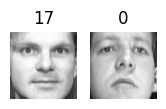

Cluster 12


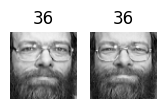

Cluster 13


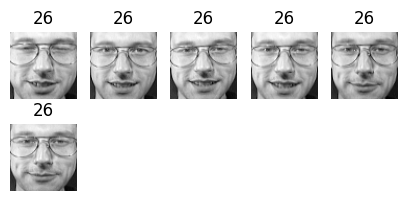

Cluster 14


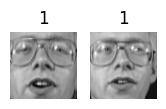

Cluster 15


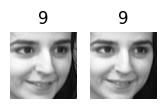

Cluster 16


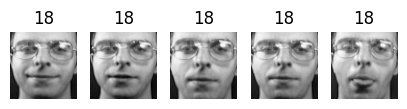

Cluster 17


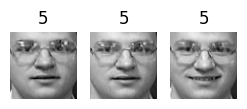

Cluster 18


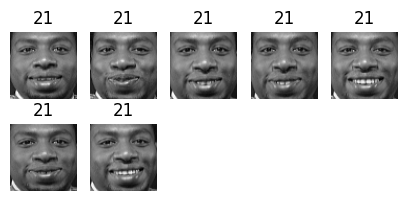

Cluster 19


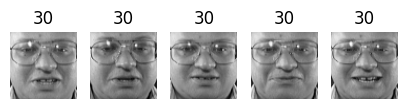

Cluster 20


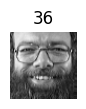

Cluster 21


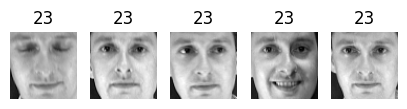

Cluster 22


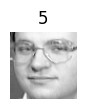

Cluster 23


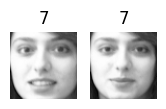

Cluster 24


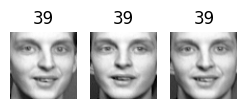

Cluster 25


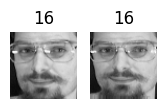

Cluster 26


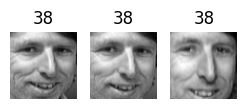

Cluster 27


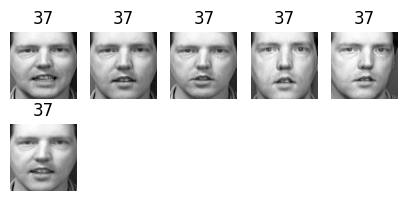

Cluster 28


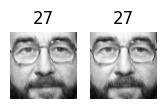

Cluster 29


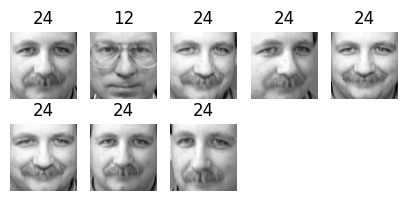

Cluster 30


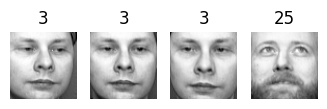

Cluster 31


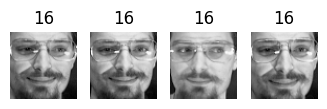

Cluster 32


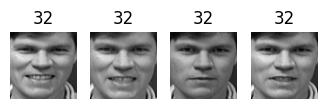

Cluster 33


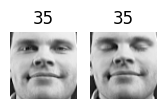

Cluster 34


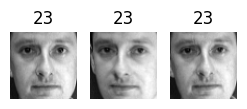

Cluster 35


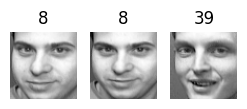

Cluster 36


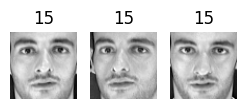

Cluster 37


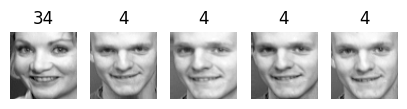

Cluster 38


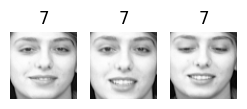

Cluster 39


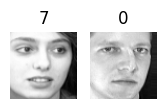

Cluster 40


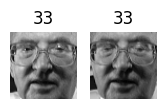

Cluster 41


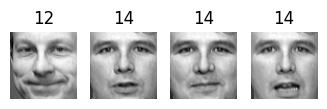

Cluster 42


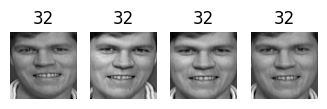

Cluster 43


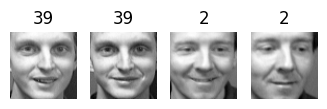

Cluster 44


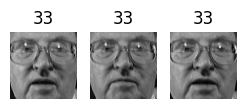

Cluster 45


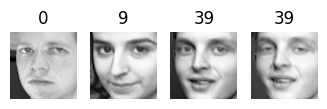

Cluster 46


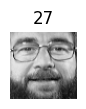

Cluster 47


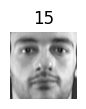

Cluster 48


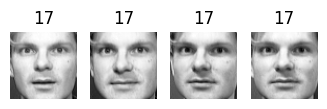

Cluster 49


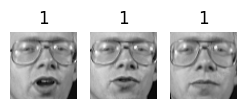

Cluster 50


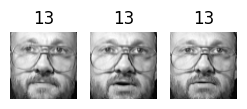

Cluster 51


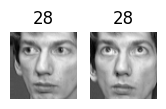

Cluster 52


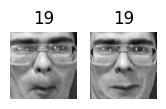

Cluster 53


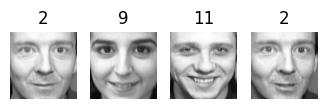

Cluster 54


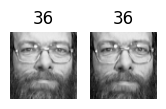

Cluster 55


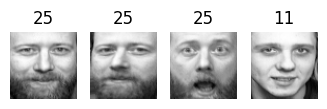

Cluster 56


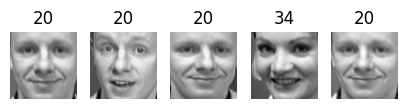

Cluster 57


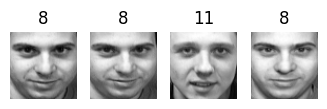

Cluster 58


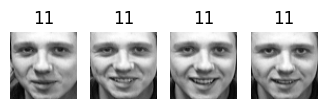

Cluster 59


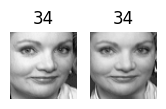

Cluster 60


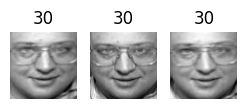

Cluster 61


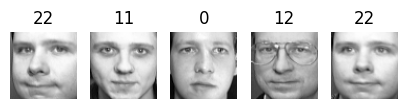

Cluster 62


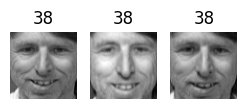

Cluster 63


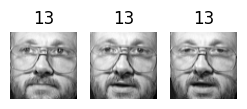

Cluster 64


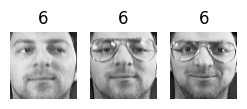

Cluster 65


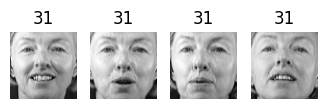

Cluster 66


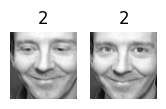

Cluster 67


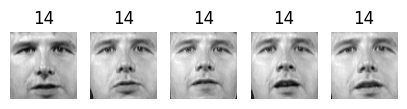

Cluster 68


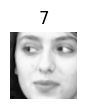

Cluster 69


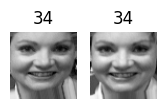

Cluster 70


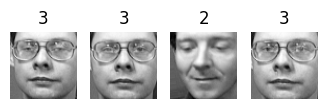

Cluster 71


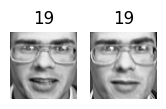

Cluster 72


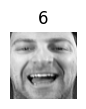

Cluster 73


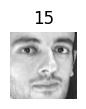

Cluster 74


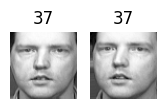

Cluster 75


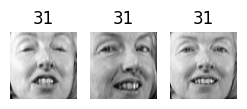

Cluster 76


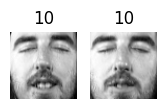

Cluster 77


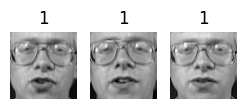

Cluster 78


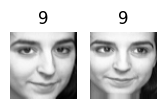

Cluster 79


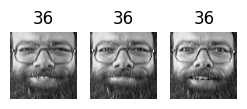

Cluster 80


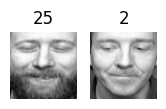

Cluster 81


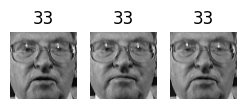

Cluster 82


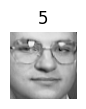

Cluster 83


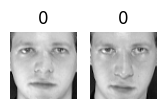

Cluster 84


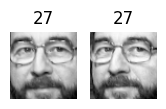

Cluster 85


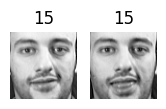

Cluster 86


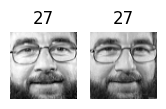

Cluster 87


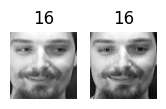

Cluster 88


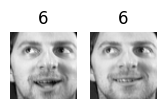

Cluster 89


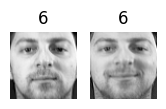

Cluster 90


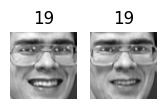

Cluster 91


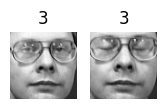

Cluster 92


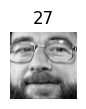

Cluster 93


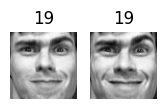

Cluster 94


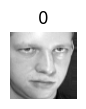

Cluster 95


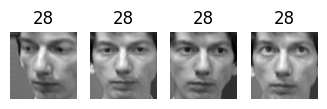

Cluster 96


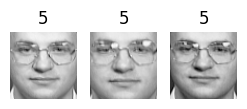

Cluster 97


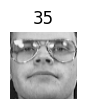

Cluster 98


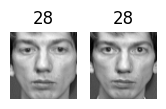

Cluster 99


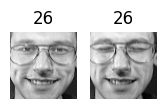

Cluster 100


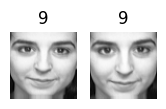

Cluster 101


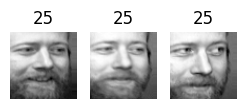

Cluster 102


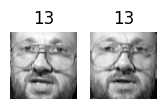

Cluster 103


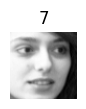

Cluster 104


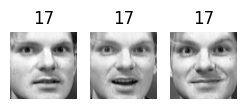

Cluster 105


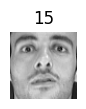

Cluster 106


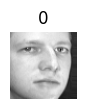

Cluster 107


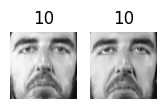

Cluster 108


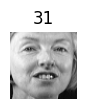

Cluster 109


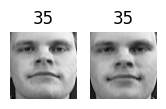

In [13]:
def plot_faces(faces, labels, n_cols=5):
    faces = faces.reshape(-1, 64, 64)
    n_rows = (len(faces) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols, n_rows * 1.1))
    for index, (face, label) in enumerate(zip(faces, labels)):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(face, cmap="gray")
        plt.axis("off")
        plt.title(label)
    plt.show()

for cluster_id in np.unique(best_model.labels_):
    print("Cluster", cluster_id)
    in_cluster = best_model.labels_==cluster_id
    faces = X_train[in_cluster]
    labels = y_train[in_cluster]
    plot_faces(faces, labels)

Exercise 11. Continuing with the Olivetti faces dataset, train a classifier to predict which person is represented in each picture, and evaluate it on the validation set.


In [14]:
best_model.labels_

array([ 50,  22,  30,   2,   4,  56,  29,  10,  58,  63,  49,  78,   5,
        27,  77,   5,  10,  32,  79,  81,  25,  81,  71,  39,  21,  40,
       107,  12,  52,  50,  73,   6,  69,  41,   5,  45,  57,  37,  42,
        51,  69,  72,  30,  75,  18,  18,  62,  63,  35,  29, 101,  59,
        96,  99,  81,  87,  37,  74,  56,  10,  56,  35,  30,  88, 100,
        19,   3,  65,  16,  94,  87,  78,  55,  27,  16,  26,  14,   4,
        24,  17,  65,  29,  38,  98,  41,  42,  40,  55,  91,  65,  43,
        42, 107,  60,  16,  15,  70,   6,  77,  29,  65,  23,  85,   8,
        24,  95,  23,  31,  29,  13,   5,  13,  13,  35,  70,  48,  25,
        13,  84,   0,  19,  67,  32,   7,  55,  54,  26,  18,  79,  56,
        19,  93,  53,  98, 100,   0,  86,  31,  50,  41,   7,  29, 106,
        95,   4,  37,  31,  43,  26,   0,  48, 101,  82,  96,  15,  57,
         6,  49,  61,  95,   0,  28,  16,  76,  93,  27,  39,  45,  66,
        80,  83,  29,  44,  13,   0,  11,  13,   8, 101,  49,  2

In [15]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

clf = RandomForestClassifier(n_estimators= 150, random_state=42)
clf.fit(X_train_pca, y_train)
clf.score(X_valid_pca, y_valid)



0.95

Exercise: Next, use K-Means as a dimensionality reduction tool, and train a classifier on the reduced set. Search for the number of clusters that allows the classifier to get the best performance: what performance do you reach? What if you append the features from the reduced set to the original features (again, serching for the best number of clusters)?

In [16]:
# in order to use K-Means as a dimensionality reduction tool,
# we need to use soft clustering instead of hard clustering
# now we use the best model from before (not optimizing over the result of
# the second classifier)
kmeans_soft = KMeans(n_clusters=best_k, random_state=42)
kmeans_soft.fit(X_train_pca)
X_train_kmeans = kmeans_soft.transform(X_train_pca)

clf = RandomForestClassifier(n_estimators= 150, random_state=42)
clf.fit(X_train_kmeans, y_train)
clf.score(kmeans_soft.transform(X_valid_pca), y_valid)

0.75

In [17]:
# Now: PCA --> KMeans --> RandomForestClassifier
# and the variable on which to optimize the RFC will be the number of clusters

ks = range(5,150, 5)  # 5,10,15,20,...,150
kmeans_models = []
scores = []

for k in ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca) # fit kmeans on X_train_pca
    X_train_kmeans = kmeans.transform(X_train_pca) # reduce the dimension: create the new training set
      # X_train_kmeans (k parameters)
    kmeans_models.append(kmeans)
    clf = RandomForestClassifier(n_estimators= 150, random_state=42)
    clf.fit(X_train_kmeans, y_train)
    score = clf.score(kmeans.transform(X_valid_pca), y_valid)
    scores.append(score)
    print(k, score)

best_index = np.argmax(scores) ## the index of the silhouettes vectors
best_k = ks[best_index] # the corresponding number of clusters
best_score = scores[best_index] # the corresponding silhouette score
print(f"best k: {best_k}")
print(f"best score: {best_score}")



5 0.3
10 0.5
15 0.6
20 0.625
25 0.65
30 0.675
35 0.625
40 0.65
45 0.625
50 0.725
55 0.75
60 0.775
65 0.75
70 0.825
75 0.75
80 0.725
85 0.775
90 0.775
95 0.775
100 0.775
105 0.8
110 0.75
115 0.75
120 0.75
125 0.725
130 0.75
135 0.675
140 0.75
145 0.8
best k: 70
best score: 0.825


In the previous code, the RFC was trained on the training set that went through a dimensionality reduction performed by KMeans. What if we happend the features from the reduced set to the original features (again, serching for the best number of clusters)?

In [18]:
ks = range(5, 150, 5)
scores = []

for k in ks:
    print(f"Testing k={k}")
    # 1. Learn clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_train_pca)

    # Create KMeans features
    X_train_kmeans = kmeans.transform(X_train_pca)
    X_valid_kmeans = kmeans.transform(X_valid_pca)

    # Append original PCA features + KMeans features
    X_train_combined = np.c_[X_train_pca, X_train_kmeans]

    X_valid_combined = np.c_[X_valid_pca, X_valid_kmeans]

    # Classifier
    clf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)

    clf.fit(X_train_combined, y_train)

    score = clf.score(X_valid_combined, y_valid)
    scores.append(score)

    print(k, score)


best_index = np.argmax(scores)
best_k = list(ks)[best_index]
best_score = scores[best_index]

print(f"Best k: {best_k}")
print(f"Best score: {best_score}")

Testing k=5
5 0.975
Testing k=10
10 0.9
Testing k=15
15 0.9
Testing k=20
20 0.925
Testing k=25
25 0.825
Testing k=30
30 0.875
Testing k=35
35 0.8
Testing k=40
40 0.85
Testing k=45
45 0.875
Testing k=50
50 0.85
Testing k=55
55 0.875
Testing k=60
60 0.9
Testing k=65
65 0.875
Testing k=70
70 0.9
Testing k=75
75 0.9
Testing k=80
80 0.9
Testing k=85
85 0.85
Testing k=90
90 0.9
Testing k=95
95 0.85
Testing k=100
100 0.875
Testing k=105
105 0.925
Testing k=110
110 0.825
Testing k=115
115 0.85
Testing k=120
120 0.85
Testing k=125
125 0.85
Testing k=130
130 0.875
Testing k=135
135 0.8
Testing k=140
140 0.85
Testing k=145
145 0.825
Best k: 5
Best score: 0.975
